<a href="https://colab.research.google.com/github/saneeshaparna39-dotcom/ML-assignment/blob/main/CNN_VGG_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import required libraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import utils

load and sample cifar10 dataset

In [ ]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Display the shapes of the loaded data
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 99s 1us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [ ]:
x_train,y_train = x_train[:100],y_train[:100]
x_test,y_test = x_test[:100],y_test[:100]

resize images to 224*224

In [ ]:
x_train = tf.image.resize(x_train, (224, 224))
x_test = tf.image.resize(x_test, (224, 224))

normalization

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

convert x_train and x_test to 3 channels for VGG16

In [ ]:
print(f"x_train shape after channel conversion: {x_train.shape}")
print(f"x_test shape after channel conversion: {x_test.shape}")

x_train shape after channel conversion: (100, 224, 224, 3, 3)
x_test shape after channel conversion: (100, 224, 224, 3, 3)


one hot encoding

In [ ]:
y_train = utils.to_categorical(y_train)
y_test = utils.to_categorical(y_test)

### Re-preparing data for training

The previous error indicates that `x_train` and `y_train` were in an incorrect state in the runtime's memory. This cell reloads and preprocesses the data to ensure the correct shapes and values before model training.

In [ ]:
# Load the CIFAR-10 dataset again to ensure a fresh start
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

# Sample the data (as per previous notebook step)
x_train, y_train = x_train_raw[:100], y_train_raw[:100]
x_test, y_test = x_test_raw[:100], y_test_raw[:100]

# Resize images to 224x224 (as per previous notebook step)
x_train = tf.image.resize(x_train, (224, 224))
x_test = tf.image.resize(x_test, (224, 224))

# Normalize pixel values to [0, 1] (as per previous notebook step)
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode the labels (as per previous notebook step)
y_train = utils.to_categorical(y_train)
y_test = utils.to_categorical(y_test)

print(f"x_train shape after re-preparation: {x_train.shape}")
print(f"y_train shape after re-preparation: {y_train.shape}")
print(f"x_test shape after re-preparation: {x_test.shape}")
print(f"y_test shape after re-preparation: {y_test.shape}")

x_train shape after re-preparation: (100, 224, 224, 3)
y_train shape after re-preparation: (100, 10)
x_test shape after re-preparation: (100, 224, 224, 3)
y_test shape after re-preparation: (100, 10)


load pretrained VGG16 without top layers

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

freeze basemodel layers(feature extraction)

In [ ]:
for layer in base_model.layers:
  layer.trainable = False

add custom top layers

In [ ]:
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(10, activation='softmax')(x)

create the final model

In [ ]:
model = Model(inputs = base_model.input,outputs = predictions)

In [ ]:
model = Model(inputs = base_model.input,outputs = predictions)

compile the model(feature extraction phase)

In [ ]:
model.compile(optimizer = Adam(learning_rate = 1e-4), loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
model.compile(optimizer = Adam(learning_rate = 1e-4), loss = 'categorical_crossentropy', metrics = ['accuracy'])

train the model(only top layers)

In [ ]:
history = model.fit(x_train,y_train,epochs = 5,batch_size = 32,validation_split = 0.2)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 70s 26s/step - accuracy: 0.0875 - loss: 2.5441 - val_accuracy: 0.1500 - val_loss: 2.2687
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 63s 23s/step - accuracy: 0.2375 - loss: 2.1845 - val_accuracy: 0.2000 - val_loss: 2.2076
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 18s/step - accuracy: 0.3875 - loss: 1.9588 - val_accuracy: 0.1500 - val_loss: 2.2021
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 18s/step - accuracy: 0.2750 - loss: 2.0275 - val_accuracy: 0.2000 - val_loss: 2.1977
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 17s/step - accuracy: 0.3125 - loss: 1.8828 - val_accuracy: 0.2000 - val_loss: 2.1473


fine-tue some convolutional layers

In [ ]:
for layer in base_model.layers[-4:]:
  layer.trainable = True

compile again(after unfreezing)

In [ ]:
model.compile(optimizer = Adam(learning_rate = 1e-5), loss = 'categorical_crossentropy', metrics = ['accuracy'])

evaluate on test set

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("test accuracy",test_acc)
print("test loss",test_loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 54s 12s/step - accuracy: 0.1700 - loss: 2.3607
test accuracy 0.17000000178813934
test loss 2.360690116882324


plot accuracy graph

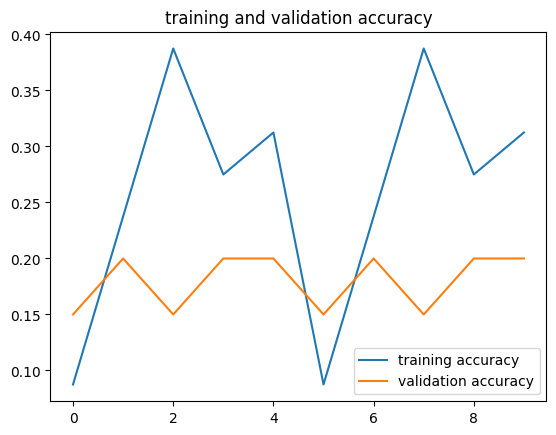

In [ ]:
plt.plot(history.history['accuracy'] + history.history['accuracy'],label = 'training accuracy')
plt.plot(history.history['val_accuracy'] + history.history['val_accuracy'],label = 'validation accuracy')
plt.legend()
plt.title('training and validation accuracy')
plt.show()